# Router Pattern



A router pattern sends each request to the right specialist workflow or downstream agent.



## Stack

- Framework: LangChain routing chain

- LLM: local Ollama via `ChatOllama(model="llama3.1:latest")`

- Pattern goal: specialization by domain



## When to use it

- You have multiple business domains

- One general agent is becoming too broad

## Architecture



```mermaid

graph LR

    U[Incoming Request] --> R[LLM Router]

    R --> T[Travel Skill]

    R --> F[Finance Skill]

    R --> C[Calendar Skill]

    R --> G[General Skill]

```

In [ ]:
from visual_diagram_helper import render_svg_flow



nodes = [

    ("input", "Incoming Request", 40, 170, "#bfdbfe"),

    ("router", "Router", 250, 170, "#bbf7d0"),

    ("travel", "Travel Skill", 470, 80, "#fde68a"),

    ("finance", "Finance Skill", 470, 170, "#fde68a"),

    ("calendar", "Calendar Skill", 470, 260, "#fde68a"),

    ("output", "Routed Result", 900, 170, "#ddd6fe"),

]

edges = [

    ("input", "router"),

    ("router", "travel"),

    ("router", "finance"),

    ("router", "calendar"),

    ("travel", "output"),

    ("finance", "output"),

    ("calendar", "output"),

]



render_svg_flow("Router Pattern Visual Architecture", nodes, edges, width=1140, height=420)

In [ ]:
# Reload shared helpers so any edits to agent_patterns_common.py take effect

# without needing to restart the kernel.

import importlib

import agent_patterns_common



importlib.reload(agent_patterns_common)

print("agent_patterns_common reloaded.")

### Router Pattern State Graph

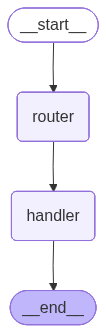

{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Classify the request into one label only.\nValid labels: travel, finance, calenda"}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}
{"level": "INFO", "event_type": "route_selected", "route": "travel", "request": "Book a hotel near the conference venue"}
{"level": "INFO", "event_type": "route_handled", "route": "travel"}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Classify the request into one label only.\nValid labels: travel, finance, calenda"}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}
{"level": "INFO", "event_type": "route_selected", "route": "finance", "request": "Help me review this invoice"}
{"level": "INFO", "event_type": "route_handled", "route": "finance"}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Classify the request into one label only.\nValid labels: travel, finan

[{'request': 'Book a hotel near the conference venue',
  'route': 'travel',
  'result': 'Travel skill selected: search flights, hotels, and destination context.',
  'history': ['Route selected: travel', 'Handled by: travel']},
 {'request': 'Help me review this invoice',
  'route': 'finance',
  'result': 'Finance skill selected: inspect invoice, payment state, and exceptions.',
  'history': ['Route selected: finance', 'Handled by: finance']},
 {'request': 'Find a meeting slot for next week',
  'route': 'calendar',
  'result': 'Calendar skill selected: inspect availability and propose meeting slots.',
  'history': ['Route selected: calendar', 'Handled by: calendar']}]

In [ ]:
from langgraph.graph import END, START, StateGraph



from agent_pattern_states import RouterState

from agent_patterns_common import (

    append_history,

    build_checkpointer,

    choose_label,

    get_local_llm,

    invoke_with_retry,

    log_event,

    render_state_graph,

)





llm = get_local_llm()





def router_node(state: RouterState) -> RouterState:

    prompt = (

        "Classify the request into one label only.\n"

        "Valid labels: travel, finance, calendar, general.\n"

        "Return ONLY the label token with no punctuation.\n"

        f"Request: {state['request']}"

    )

    raw_label = invoke_with_retry(llm, prompt)

    label = choose_label(raw_label, ["travel", "finance", "calendar", "general"], "general")

    log_event("info", "route_selected", route=label, request=state["request"])

    return {

        "route": label,

        "history": append_history(state.get("history"), f"Route selected: {label}"),

    }





def handler_node(state: RouterState) -> RouterState:

    handlers = {

        "travel": "Travel skill selected: search flights, hotels, and destination context.",

        "finance": "Finance skill selected: inspect invoice, payment state, and exceptions.",

        "calendar": "Calendar skill selected: inspect availability and propose meeting slots.",

        "general": "General skill selected: provide a fallback answer.",

    }

    result = handlers[state["route"]]

    log_event("info", "route_handled", route=state["route"])

    return {

        "result": result,

        "history": append_history(state["history"], f"Handled by: {state['route']}"),

    }





builder = StateGraph(RouterState)

builder.add_node("router", router_node)

builder.add_node("handler", handler_node)

builder.add_edge(START, "router")

builder.add_edge("router", "handler")

builder.add_edge("handler", END)



graph = builder.compile(checkpointer=build_checkpointer())

render_state_graph(graph, "Router Pattern State Graph")



requests = [

    "Book a hotel near the conference venue",

    "Help me review this invoice",

    "Find a meeting slot for next week",

]



results = []

for index, request in enumerate(requests, start=1):

    results.append(

        graph.invoke(

            {"request": request, "route": "", "result": "", "history": []},

            config={"configurable": {"thread_id": f"router-demo-{index}"}},

        )

    )



results

## Design insight



Routing keeps each downstream skill small. It is usually better to classify once and execute a focused workflow than to let one general agent do everything.